# Notebook 5: Build training datasets

This is the fifth notebook in the sequence for the HRS Botany project.

In it we will build training datasets using EnMAP image hyperspectral bands as features and species-specific presesence/absence values as targets. There will be one training dataset with columns for each hyperspectral band and one column per species P/A. The dataset will consist of one row per pixel, and will also contain plot / enmap image id information.


__Notebook Inputs:__
- Gridded Species Presence-Absence geojsons by EnMAP Pixel  (_data/output_tables/{plot_id}/{enmap_image_id}/presence_absence.geojson_)
- Trimmed EnMAP tiffs and sidecar metadata JSONs 

__Notebook Outputs:__
- Hyperspectral Bands + Species P/A Training Dataset  (_data/output_tables/{plot_id}/{enmap_image_id}/counts.geojson_)


In [19]:
import geopandas as gpd
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Handle .tif or .tiff
tiff_candidates = list(scene_dir.glob("*_SPECTRAL_IMAGE_COG.tif*"))
tiff_path = tiff_candidates[0] if tiff_candidates else None

json_candidates = list(scene_dir.glob("*_SPECTRAL_IMAGE_COG.json"))
json_path = json_candidates[0] if json_candidates else None

In [ ]:
from tqdm import tqdm
import geopandas as gpd
import pandas as pd
import rasterio
from pathlib import Path
import numpy as np
import json

def load_enmap_band_values(tiff_path, pixel_geom, band_indices=None):
    with rasterio.open(tiff_path) as src:
        if band_indices is None:
            band_indices = list(range(1, src.count + 1))  # 1-based indexing
        centroid = pixel_geom.centroid
        row, col = src.index(centroid.x, centroid.y)
        band_values = []
        for i in band_indices:
            band = src.read(i)
            band_values.append(band[row, col])
    return band_values

def build_dataset(
    enmap_root,
    pa_root,
    band_indices=None,
    output_path=None,
):
    all_rows = []
    enmap_root = Path(enmap_root)
    pa_root = Path(pa_root)

    print(f"Scanning EnMAP root: {enmap_root}")
    for plot_dir in tqdm(list(enmap_root.iterdir()), desc="Plot directories"):
        if not plot_dir.is_dir():
            continue
        plot_id = plot_dir.name
        print(f"\nProcessing plot: {plot_id}")

        for scene_dir in plot_dir.iterdir():
            scene_id = scene_dir.name
            print(f"  Scene: {scene_id}")
            # Handle .tif or .tiff
            tiff_candidates = list(scene_dir.glob("*_SPECTRAL_IMAGE_COG.tif*"))
            tiff_path = tiff_candidates[0] if tiff_candidates else None

            json_candidates = list(scene_dir.glob("*_SPECTRAL_IMAGE_COG.json"))
            json_path = json_candidates[0] if json_candidates else None
            pa_geojson = pa_root / plot_id / scene_id / "presence_absence.geojson"

            if not tiff_path:
                print(f"    ⚠️ Missing TIFF in {scene_dir}")
                continue
            if not json_path:
                print(f"    ⚠️ Missing JSON in {scene_dir}")
                continue
            if not pa_geojson.exists():
                print(f"    ⚠️ Missing presence_absence.geojson: {pa_geojson}")
                continue

            try:
                gdf = gpd.read_file(pa_geojson)
                gdf = gdf[gdf["valid_pixel"] == True].copy()
                print(f"    ✅ Loaded {len(gdf)} valid pixels")

                with open(json_path) as f:
                    meta = json.load(f)

                for _, row in gdf.iterrows():
                    pixel_geom = row.geometry
                    enmap_values = load_enmap_band_values(tiff_path, pixel_geom, band_indices)

                    pixel_data = {
                        "plot_id": plot_id,
                        "scene_id": scene_id,
                        "pixel_id": row["pixel_id"],
                        "row": row["row"],
                        "col": row["col"],
                        "centroid": row["centroid"],
                    }

                    # Add EnMAP band values
                    for i, val in enumerate(enmap_values, 1):
                        pixel_data[f"band_{i}"] = val

                    # Add species columns
                    species_cols = [k for k in row.index if k.isdigit()]
                    for s in species_cols:
                        pixel_data[s] = row[s]

                    all_rows.append(pixel_data)

            except Exception as e:
                print(f"    ❌ Error processing {scene_id}: {e}")
                continue

    print(f"\n✅ Total pixels added: {len(all_rows)}")

    df = pd.DataFrame(all_rows)

    if not df.empty:
        if output_path:
            print(f"📁 Saving to {output_path}")
            df.to_parquet(output_path, index=False)
        else:
            print("⚠️ No output path provided. Returning DataFrame only.")
    else:
        print("⚠️ No data found. Check warnings above.")

    return df


In [ ]:
from tqdm import tqdm
import geopandas as gpd
import pandas as pd
import rasterio
from pathlib import Path
import numpy as np
import json

def load_enmap_band_values(tiff_path, pixel_geom, band_indices=None):
    with rasterio.open(tiff_path) as src:
        if band_indices is None:
            band_indices = list(range(1, src.count + 1))  # 1-based indexing
        centroid = pixel_geom.centroid
        row, col = src.index(centroid.x, centroid.y)
        band_values = []
        for i in band_indices:
            band = src.read(i)
            band_values.append(band[row, col])
    return band_values

def build_dataset(
    enmap_root,
    pa_root,
    band_indices=None,
    output_path=None,
):
    all_rows = []
    enmap_root = Path(enmap_root)
    pa_root = Path(pa_root)

    print(f"Scanning EnMAP root: {enmap_root}")
    for plot_dir in tqdm(list(enmap_root.iterdir()), desc="Plot directories"):
        if not plot_dir.is_dir():
            continue
        plot_id = plot_dir.name
        print(f"\nProcessing plot: {plot_id}")

        for scene_dir in plot_dir.iterdir():
            scene_id = scene_dir.name
            print(f"  Scene: {scene_id}")
            tiff_path = next(scene_dir.glob("*_SPECTRAL_IMAGE_COG.tiff"), None)
            json_path = next(scene_dir.glob("*_SPECTRAL_IMAGE_COG.json"), None)
            pa_geojson = pa_root / plot_id / scene_id / "presence_absence.geojson"

            if not tiff_path:
                print(f"    ⚠️ Missing TIFF in {scene_dir}")
                continue
            if not json_path:
                print(f"    ⚠️ Missing JSON in {scene_dir}")
                continue
            if not pa_geojson.exists():
                print(f"    ⚠️ Missing presence_absence.geojson: {pa_geojson}")
                continue

            try:
                gdf = gpd.read_file(pa_geojson)
                gdf = gdf[gdf["valid_pixel"] == True].copy()
                print(f"    ✅ Loaded {len(gdf)} valid pixels")

                with open(json_path) as f:
                    meta = json.load(f)

                for _, row in gdf.iterrows():
                    pixel_geom = row.geometry
                    enmap_values = load_enmap_band_values(tiff_path, pixel_geom, band_indices)

                    pixel_data = {
                        "plot_id": plot_id,
                        "scene_id": scene_id,
                        "pixel_id": row["pixel_id"],
                        "row": row["row"],
                        "col": row["col"],
                        "centroid": row["centroid"],
                    }

                    # Add EnMAP band values
                    for i, val in enumerate(enmap_values, 1):
                        pixel_data[f"band_{i}"] = val

                    # Add species columns
                    species_cols = [k for k in row.index if k.isdigit()]
                    for s in species_cols:
                        pixel_data[s] = row[s]

                    all_rows.append(pixel_data)

            except Exception as e:
                print(f"    ❌ Error processing {scene_id}: {e}")
                continue

    print(f"\n✅ Total pixels added: {len(all_rows)}")

    df = pd.DataFrame(all_rows)

    if not df.empty:
        if output_path:
            print(f"📁 Saving to {output_path}")
            df.to_parquet(output_path, index=False)
        else:
            print("⚠️ No output path provided. Returning DataFrame only.")
    else:
        print("⚠️ No data found. Check warnings above.")

    return df


In [55]:
enmap_root="/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/enmap_downloads/enmap_downloads_20250708"
pa_root="/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/output_tables"


df = build_dataset(
    enmap_root,
    pa_root,
    band_indices=None,
    output_path=None,
)

Scanning EnMAP root: /Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/enmap_downloads/enmap_downloads_20250708


Plot directories: 100%|██████████| 27/27 [00:00<00:00, 2277.91it/s]


Processing plot: 0112
  Scene: ENMAP01-____L2A-DT0000001029_20220609T193006Z_002_V010400_20231221T171725Z
    ⚠️ Missing TIFF in /Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/enmap_downloads/enmap_downloads_20250708/0112/ENMAP01-____L2A-DT0000001029_20220609T193006Z_002_V010400_20231221T171725Z
  Scene: ENMAP01-____L2A-DT0000041496_20230911T193100Z_006_V010502_20250210T191823Z
    ⚠️ Missing TIFF in /Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/enmap_downloads/enmap_downloads_20250708/0112/ENMAP01-____L2A-DT0000041496_20230911T193100Z_006_V010502_20250210T191823Z

Processing plot: 0115
  Scene: ENMAP01-____L2A-DT0000101872_20241112T192628Z_011_V010501_20241120T235556Z
    ⚠️ Missing TIFF in /Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/notebooks/pipeline/data/enmap_downloads/enmap_downloads_20250708/0115/ENMAP01-____L2A-DT0000101872_20241112T192628Z_011_V010501_20241120T235556Z
  Scene: ENMAP01-____L2A-DT

In [49]:
df

""


In [6]:
geojson_path = './data/output_tables/0087/ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z/presence_absence.geojson'
tiff_path = './data/enmap_downloads/enmap_downloads_20250708/0087/ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z/ENMAP01-____L2A-DT0000101230_20241104T191929Z_009_V010501_20241113T041107Z-SPECTRAL_IMAGE_COG.tiff'

pa_trainer = PresenceAbsenceTrainer(geojson_path, tiff_path)

In [8]:
df = pa_trainer.extract_training_data(target_species="8892957")

(0.0, 4320.1)

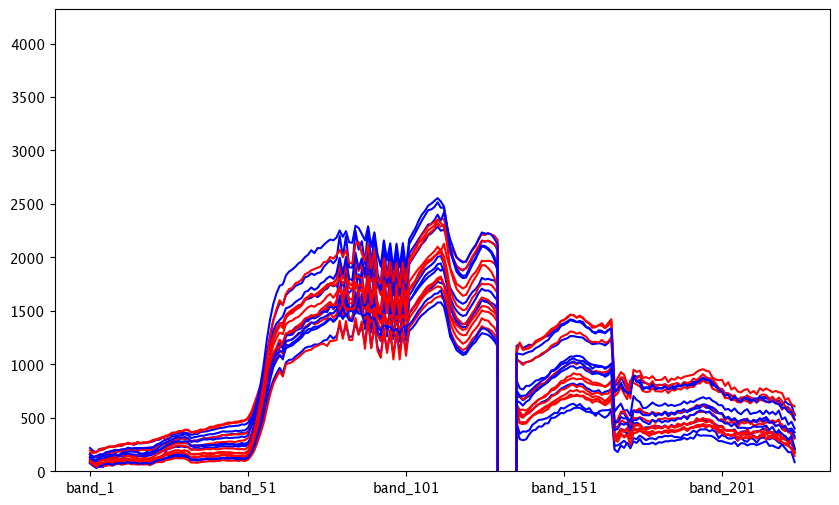

In [ ]:
color_map = {0: 'red', 1: 'blue'}



fig, ax = plt.subplots(figsize=(10, 6))
for i in range(20):
    df.iloc[i][:-1].plot(ax=ax, label=f'Band {i+1}', color=color_map[df.iloc[i].target])

ax.set_ylim(0)


In [28]:
df.min().idxmin()

'band_131'

In [34]:
band_cols = ['band_' + str(item) for item in np.arange(120, 140,1).tolist()]

df[band_cols].head()

,band_120,band_121,band_122,band_123,band_124,band_125,band_126,band_127,band_128,band_129,band_130,band_131,band_132,band_133,band_134,band_135,band_136,band_137,band_138,band_139
0,1351,1402,1454,1497,1555,1602,1586,1578,1554,1515,1459,-32768,-32768,-32768,-32768,-32768,572,527,518,530
1,1274,1326,1375,1414,1458,1504,1493,1490,1472,1441,1391,-32768,-32768,-32768,-32768,-32768,589,516,500,531
2,1386,1432,1475,1505,1540,1605,1589,1596,1574,1558,1511,-32768,-32768,-32768,-32768,-32768,848,776,764,799
3,1583,1634,1676,1702,1742,1808,1793,1800,1789,1784,1731,-32768,-32768,-32768,-32768,-32768,1046,1027,1006,1020
4,1903,1937,1996,2040,2083,2152,2148,2153,2140,2124,2065,-32768,-32768,-32768,-32768,-32768,1173,1188,1152,1168


Several spectral ranges were excluded due to strong water vapor absorption, including bands between 1330.86 and 1461.11 nm (with bands 131–135 already excluded from the source data) and between 1796 and 1938 nm.

In [40]:
df.target

0     1
1     0
2     1
3     1
4     1
5     1
6     0
7     1
8     0
9     0
10    0
11    0
12    0
13    1
14    0
15    0
16    1
17    1
18    0
19    1
20    0
21    0
22    1
23    0
24    0
25    0
26    0
27    0
28    0
29    1
Name: target, dtype: int64